In [1]:
import jax
jax.config.update("jax_enable_x64", True)


In [ ]:
import os
import time
from datetime import datetime

import numpy as np
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

# --- new (scene) API ---------------------------------------------------------
from gigalens.jax.scene import Component, Plane, LensModel
from gigalens.jax.profiles.mass.epl import EPL
from gigalens.jax.profiles.light.sersic import SersicEllipse
from gigalens.jax.cosmo import w0waCDM_Cosmo
from gigalens.jax.scene_prob_model import ImageData, ProbModel
from gigalens.jax.scene_simulator import SceneSimulator
from gigalens.simulator import SimulatorConfig

# --- research-side pipeline / diagnostics (gigalens_research) ----------------
from gigalens_research.inference_utils import (
    InferenceContext, Pipeline, MAPStage, BridgeStage, MCLMCStage,
)
from gigalens_research.plotting import PosteriorReport, PipelineReport
import photutils.psf as psf
print('jax', jax.__version__, '| devices', jax.devices())

In [3]:
import bullseye
import importlib
importlib.reload(bullseye)
from bullseye import make_5spl_bullseye, standard_pipeline

In [ ]:
#! THESE ARE DUPLICATED IN THE BULLSEYE FILE, NEED TO CHANGE BOTH
z_lens = 0.5 
z_source1 = 1.0
z_source2 = 1.5
z_source3 = 4.0
z_source4 = 7.0
z_source5 = 13.0

prob_model, prob_model_dr, truth_scene, truth_def_ratio = make_5spl_bullseye(sample_wa=True, snr_scale=4., use_DESI_cosmo_centroids=True)
ctx = InferenceContext.from_prob_model(prob_model)
ctx_dr = InferenceContext.from_prob_model(prob_model_dr)

In [6]:
pipeline = standard_pipeline(ctx, n_map=200)
pipeline_dr = standard_pipeline(ctx_dr, n_map=200)

In [7]:
results_dir = os.path.join(
    os.path.expanduser("~"), "GIGALens-Code", "results",
    "sample_cosmology", "5spl_wa_nfw_z13_highsnr_cosmology_desitruth",
)
results_dir_dr = os.path.join(
    os.path.expanduser("~"), "GIGALens-Code", "results",
    "sample_cosmology", "5spl_wa_nfw_z13_highsnr_dr_cosmology_desitruth",
)
artifacts = pipeline.run(out_dir=results_dir, resume=True)
artifacts_dr = pipeline_dr.run(out_dir=results_dir_dr, resume=True)


MODEL CARD — effective forward model & inference setup
  Model      : LensModel(6 planes, 1 mass + 5 light components, 44 free params, cosmo=w0waCDM)
    plane 0: redshift=0.5  mass=[NFW_ELLIPSE_SLOPE]
    plane 1: redshift=1  light=[SERSIC_ELLIPSE]
    plane 2: redshift=1.5  light=[SERSIC_ELLIPSE]
    plane 3: redshift=4  light=[SERSIC_ELLIPSE]
    plane 4: redshift=7  light=[SERSIC_ELLIPSE]
    plane 5: redshift=13  light=[SERSIC_ELLIPSE]
  Cosmology  : w0waCDM z_lens=0.5 z_source_ref=1.5  H0=70, k=0, wa=sampled(UniformBij), Om0=sampled(UniformBij), w0=sampled(UniformBij)
  Trace      : deflection_ratio  (simulator)
  Parameters : 44 free  z-order sha1=4e6bfeb1be71  dtypes={float32, float64}
  Amplitudes : lstsq=False n_basis=0 physical_reg=None
  Likelihood : mode=forward  event_size=32000  precision=float64  loss_norm=32000
    shares   : [0] ImageData 6400 (20%)  [1] ImageData 6400 (20%)  [2] ImageData 6400 (20%)  [3] ImageData 6400 (20%)  [4] ImageData 6400 (20%)
  Physicality: 0

In [ ]:
# pipeline_report = PipelineReport(pipeline)
# fig = pipeline_report.diagnostics("mclmc", chain=3)
# fig.show()

report = PosteriorReport(pipeline.posterior(), truth_x=truth_scene)
report.corner(kind="cosmology")
report.full_report()
plt.show()

In [ ]:
report_dr = PosteriorReport(pipeline_dr.posterior(), truth_x=truth_def_ratio)
report_dr.corner(kind=["geometry"])
report_dr.full_report()
plt.show()

In [8]:
ps = pipeline_dr.posterior()

In [9]:
idxes = [1,3,4,5]
dr_smps = jnp.stack([ps.flat_x[f'planes/{i}/geometry/deflection_ratio'] for i in idxes])
dr_median = jnp.median(dr_smps, axis=-1)
dr_cov = jnp.cov(dr_smps)
zs = [z_source1, z_source3, z_source4, z_source5]

In [10]:
dr_median.shape

(4,)

In [11]:


import bullseye
importlib.reload(bullseye)
from bullseye import make_prob_grid
# observed = {
#     "deflect_ratio_obs": np.expand_dims(np.array(dr_medians), 1),
#     "deflect_ratio_obs_err": np.expand_dims(np.array(dr_stds), 1),
#     "z_source": np.expand_dims(np.array(zs), 1),
# }

cos=prob_model.model.cosmo.profile
observed = {
    "deflect_ratio_obs": np.expand_dims(dr_median, 1),
    "deflect_ratio_cov": dr_cov,
    # "deflect_ratio_cov_det": jnp.abs(jnp.linalg.det(dr_cov)),
    "z_source": np.expand_dims(np.array(zs), 1),
}
like, om_w_wa_grid = make_prob_grid(observed, cos, n_grid=300, sample_wa=True)

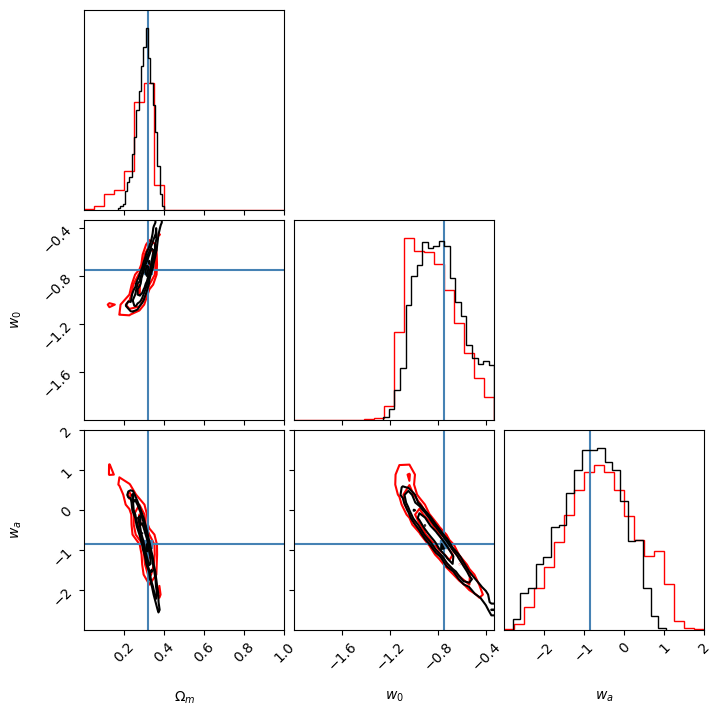

In [12]:

import corner
Omw0wa_truth = [truth_scene['cosmo'][k] for k in ['Om0', 'w0', 'wa']]
kw = lambda : dict(density=True)
stacked = np.stack([om_w_wa_grid[0].flatten(),om_w_wa_grid[1].flatten(),om_w_wa_grid[2].flatten()]).T
fig = corner.corner(stacked,color="red", weights=np.array(like.flatten()), plot_datapoints=False, plot_density=False,truths=Omw0wa_truth, hist_kwargs=kw(),)

cos_smps = np.stack([pipeline.posterior().flat_x[f'cosmo/Om0'], pipeline.posterior().flat_x[f'cosmo/w0'], pipeline.posterior().flat_x[f'cosmo/wa']]).T
corner.corner(cos_smps, fig=fig, color='black', plot_datapoints=False, plot_density=False,hist_kwargs=kw(), labels=[r'$\Omega_m$', r'$w_0$', r'$w_a$'])
plt.show()
# om_w_grid[0].shape

In [15]:
# def plot_cosmo_contour(plane_indexes=None, fig=None, color='black', levels=(0.68, 0.95)):
#     like, om_w_grid = make_prob_grid(observed, cos, n_grid=300,sample_wa=True, plane_indexes=plane_indexes)
#     # print(om_w_grid[0].shape)
#     stacked = np.stack([om_w_grid[0].flatten(),om_w_grid[1].flatten(),om_w_grid[2].flatten()]).T
#     fig = corner.corner(stacked, weights=np.array(like.flatten()), plot_datapoints=False, bins=50, contour_kwargs={'linewidths':0.5}, plot_density=False,fill_contours=True, truths=Omw0wa_truth,levels=levels, color=color, hist_kwargs=kw(), labels=[r'$\Omega_m$', r'$w_0$', r'$w_a$'], fig=fig)
#     return fig
from matplotlib.patches import Patch
def plot_cosmo_contour(plane_indexes=None, fig=None, color='black', levels=(0.68, 0.95), label=None):
    like, om_w_grid = make_prob_grid(observed, cos, n_grid=200, sample_wa=True, plane_indexes=plane_indexes)
    stacked = np.stack([om_w_grid[0].flatten(), om_w_grid[1].flatten(),om_w_grid[2].flatten()]).T
    fig = corner.corner(
        stacked,
        weights=np.array(like.flatten()),
        plot_datapoints=False,
        bins=50,
        contour_kwargs={'linewidths': 0.5},
        plot_density=False,
        fill_contours=True,
        truths=Omw0wa_truth,
        levels=levels,
        color=color,
        hist_kwargs=kw(),
        labels=[r'$\Omega_m$', r'$w_0$', r'$w_a$'],
        fig=fig,
    )

    if label is not None:
        if not hasattr(fig, '_legend_handles'):
            fig._legend_handles = []
        fig._legend_handles.append(Patch(facecolor=color, edgecolor=color, label=label))

        ndim = int(np.sqrt(len(fig.axes)))
        legend_ax = fig.axes[ndim - 1]  # top-right axis, standard corner-plot legend spot
        legend_ax.legend(handles=fig._legend_handles, loc='center', frameon=False)

    return fig

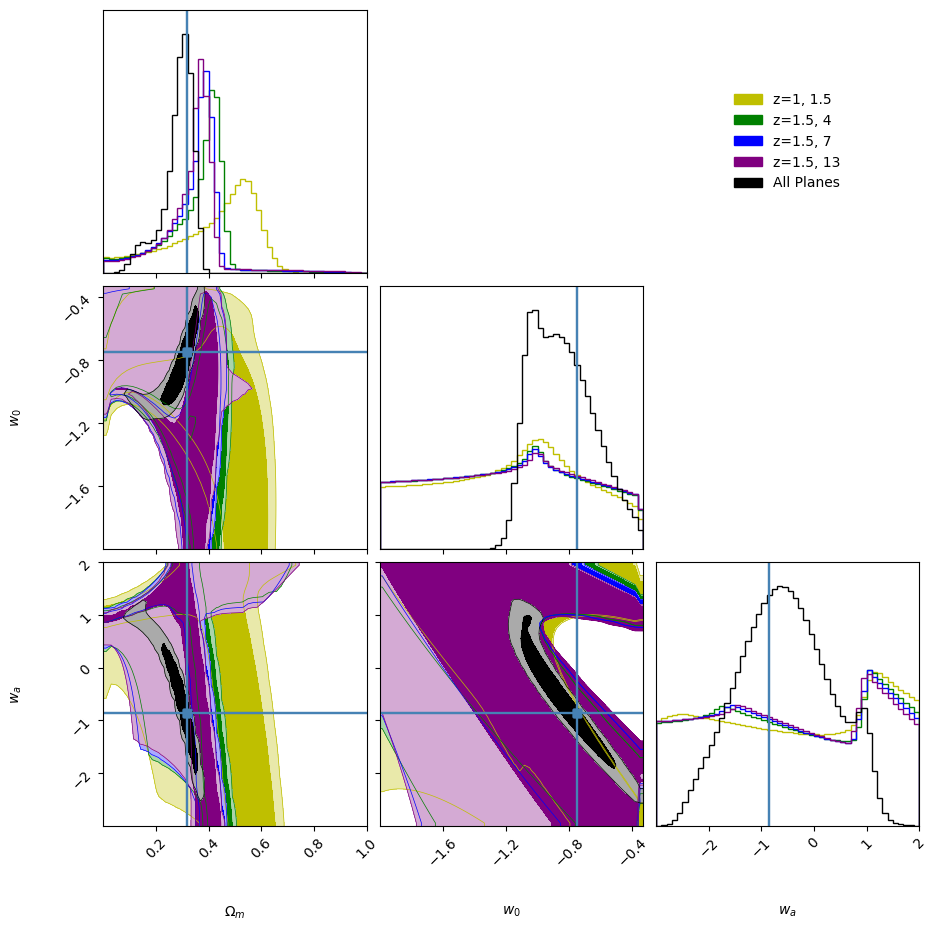

In [20]:
fig=None
for i, c, l in zip([0, 1, 2, 3], ['y', 'g', 'blue', 'purple'], ['z=1, 1.5', 'z=1.5, 4', 'z=1.5, 7', 'z=1.5, 13']):
    
    fig =plot_cosmo_contour(plane_indexes=np.array([i,]), fig=fig, color=c, label = l)
fig = plot_cosmo_contour(fig=fig, label="All Planes")
fig.set_size_inches(10, 10)
fig.show()

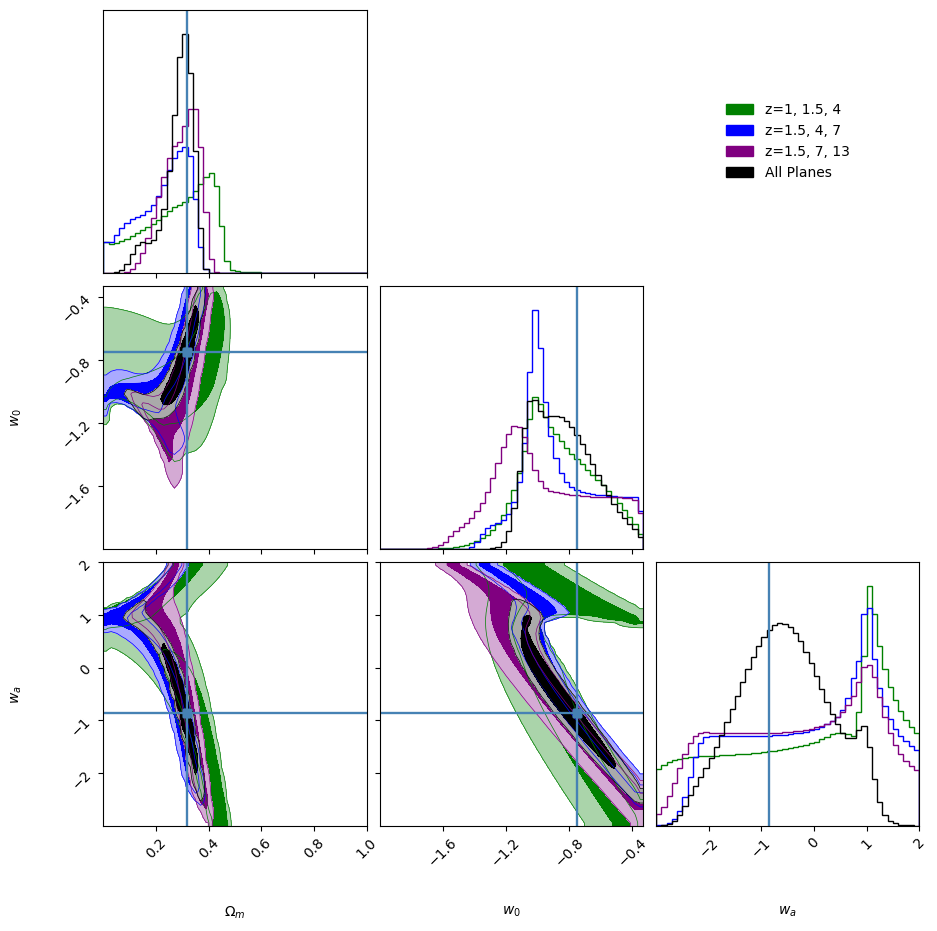

In [17]:

fig = plot_cosmo_contour(plane_indexes=np.array([0, 1,]), color='green', label="z=1, 1.5, 4")
plot_cosmo_contour(plane_indexes=np.array([1, 2,]), fig=fig, color='blue', label="z=1.5, 4, 7")
plot_cosmo_contour(plane_indexes=np.array([2, 3,]), fig=fig, color='purple', label="z=1.5, 7, 13")
plot_cosmo_contour(fig=fig, label="All Planes")
fig.set_size_inches(10, 10)
plt.show()

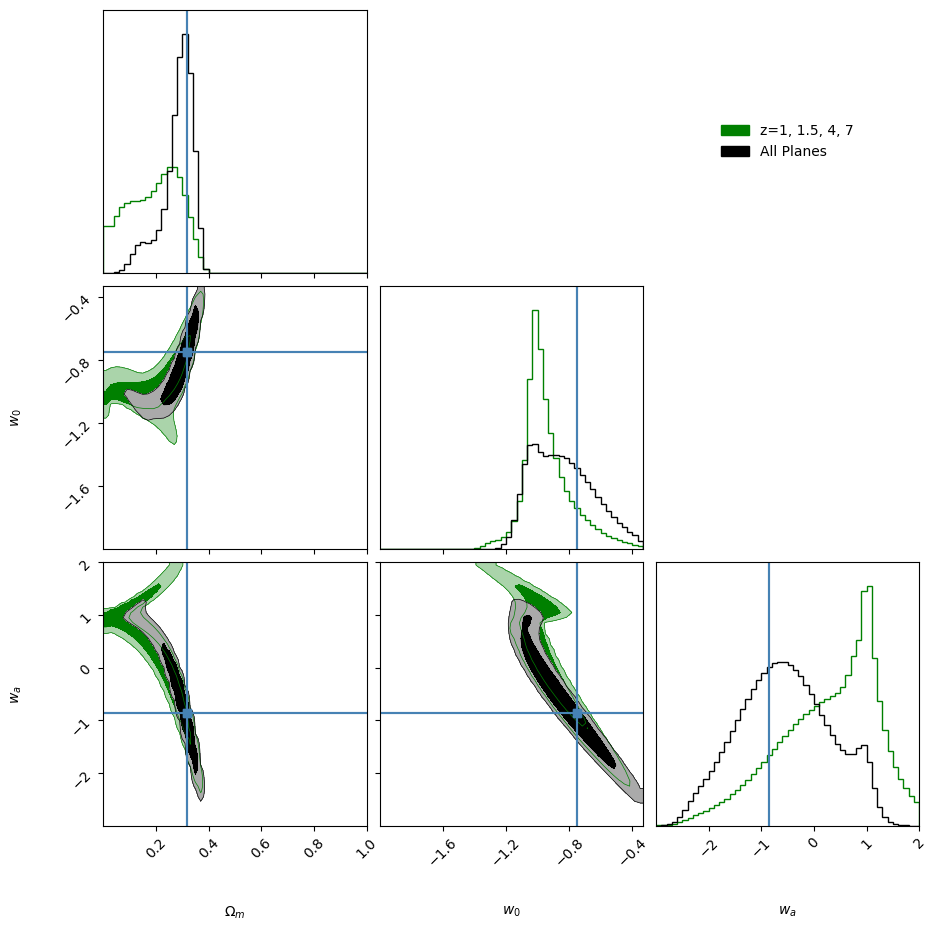

In [18]:
fig = plot_cosmo_contour(plane_indexes=np.array([0, 1, 2]), color='green', label="z=1, 1.5, 4, 7")
plot_cosmo_contour(fig=fig, label="All Planes")
fig.set_size_inches(10, 10)

In [19]:
import bullseye
importlib.reload(bullseye)
from bullseye import corner_contour_areas
lv, V, A = corner_contour_areas(om_w_wa_grid[1].flatten(),om_w_wa_grid[2].flatten(), weights=np.array(like.flatten()), levels=(0.95,), method="cells")
lv, V, A

(array([0.95]), array([5.78839286e-05]), array([0.67958333]))

In [ ]:
lv, V, A = corner_contour_areas(om_w_wa_grid[1].flatten(),om_w_wa_grid[2].flatten(), weights=np.array(like.flatten()), levels=(0.95,), method="polygons")
lv, V, A

In [ ]:
1/jnp.squeeze(A)

In [ ]:
import astropy
from astropy.table import Table
desi_w0wa = []
for i in range(4):
    desi_w0wa.append(Table.read(f"desichains/chain.{i+1}.txt", format='ascii.commented_header', data_end=-1))
desi_w0wa=astropy.table.vstack(desi_w0wa)

In [ ]:
np.array(desi_w0wa['omm']), np.array(desi_w0wa["w"]),np.array(desi_w0wa["wa"]) #.shape

In [ ]:
fig = plot_cosmo_contour()
stacked = np.stack([om_w_wa_grid[0].flatten(),om_w_wa_grid[1].flatten(),om_w_wa_grid[2].flatten()]).T
fig = corner.corner(stacked,color="red", weights=np.array(like.flatten()), plot_datapoints=False, plot_density=False,truths=Omw0wa_truth, hist_kwargs=kw(),)

In [ ]:
import corner
Omw0wa_truth = [truth_scene['cosmo'][k] for k in ['Om0', 'w0', 'wa']]
kw = lambda : dict(density=True)
stacked = np.stack([om_w_wa_grid[0].flatten(),om_w_wa_grid[1].flatten(),om_w_wa_grid[2].flatten()]).T
fig = corner.corner(stacked,color="red", weights=np.array(like.flatten()), plot_datapoints=False, plot_density=False,truths=Omw0wa_truth, hist_kwargs=kw(),)

cos_smps = np.stack([pipeline.posterior().flat_x[f'cosmo/Om0'], pipeline.posterior().flat_x[f'cosmo/w0'], pipeline.posterior().flat_x[f'cosmo/wa']]).T
corner.corner(cos_smps, fig=fig, color='black', plot_datapoints=False, plot_density=False,hist_kwargs=kw(), labels=[r'$\Omega_m$', r'$w_0$', r'$w_a$'])
plt.show()